# Lab 12 – Data Visualization

**Course:** Unstructured Data Analytics  
**Lab:** 12 – Data Visualization Module  

This notebook demonstrates the full visualization pipeline for the Music Analytics project.
It covers:
- Environment setup and library verification
- 8 static charts (matplotlib + seaborn, PNG/PDF export)
- 5 interactive charts (Plotly Express + Graph Objects, HTML export)
- Automated chart generation via `chart_generator.py`
- Visualization choice documentation (Tufte's principles)


## Part 1 – Environment Setup

In [1]:
import sys, os
from pathlib import Path

# Add src/ to path so all modules are importable
ROOT = Path().resolve().parent
sys.path.insert(0, str(ROOT / 'src'))

# Use the non-interactive Agg backend before importing pyplot
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
import plotly
import pandas as pd
import numpy as np

print('matplotlib', matplotlib.__version__)
print('seaborn', sns.__version__)
print('plotly', plotly.__version__)
print('pandas', pd.__version__)
print('numpy', np.__version__)

# Create output directories
STATIC_DIR = ROOT / 'outputs' / 'visualizations' / 'static'
INTERACTIVE_DIR = ROOT / 'outputs' / 'visualizations' / 'interactive'
STATIC_DIR.mkdir(parents=True, exist_ok=True)
INTERACTIVE_DIR.mkdir(parents=True, exist_ok=True)
print(f'Static output:      {STATIC_DIR}')
print(f'Interactive output: {INTERACTIVE_DIR}')

matplotlib 3.10.9
seaborn 0.13.2
plotly 6.7.0
pandas 3.0.2
numpy 2.4.4
Static output:      /Users/tarikhamzic/Desktop/coding projects/Unstructured_data_Music_Analysis_project/outputs/visualizations/static
Interactive output: /Users/tarikhamzic/Desktop/coding projects/Unstructured_data_Music_Analysis_project/outputs/visualizations/interactive


## Load the Cleaned Dataset

In [2]:
DATA_PATH = ROOT / 'data' / 'processed' / 'cleaned' / 'clean.csv'
df = pd.read_csv(DATA_PATH)
print(f'Shape: {df.shape}')
print(f'Columns: {df.columns.tolist()}')
df.head()

Shape: (911, 5)
Columns: ['name', 'source_collection', 'listeners', 'playcount', 'url']


,name,source_collection,listeners,playcount,url
0,Coldplay,scraped_web_data,3591113.0,324499001.0,NaN
1,Radiohead,scraped_web_data,3591113.0,324499001.0,NaN
2,The Weeknd,scraped_web_data,3591113.0,324499001.0,NaN
3,Taylor Swift,scraped_web_data,3591113.0,324499001.0,NaN
4,NaN,scraped_web_data,3591113.0,324499001.0,NaN


In [3]:
print('dtypes:')
print(df.dtypes)
print('\nnull counts:')
print(df.isnull().sum())
print('\nsource_collection value counts:')
print(df['source_collection'].value_counts())

dtypes:
name                     str
source_collection        str
listeners            float64
playcount            float64
url                      str
dtype: object

null counts:
name                 4
source_collection    0
listeners            0
playcount            0
url                  8
dtype: int64

source_collection value counts:
source_collection
lastfm_api              750
lastfm_json             150
scraped_web_data          5
lastfm_csv                2
lastfm_xml                1
document_extractions      1
ocr_results               1
image_metadata            1
Name: count, dtype: int64


---
## Part 2 – Static Charts with Matplotlib and Seaborn

All static charts are saved as **PNG (300 dpi)** and **PDF** under `outputs/visualizations/static/`.
Each chart function uses the matplotlib object-oriented API: explicit `Figure` and `Axes` objects.

In [4]:
from visualization.static_charts import (
    plot_top_artists_by_listeners,
    plot_playcount_by_source,
    plot_listeners_distribution,
    plot_playcount_distribution,
    plot_listeners_boxplot_by_source,
    plot_listeners_vs_playcount_scatter,
    plot_correlation_heatmap,
    plot_dashboard_subplots,
)
print('Static chart functions imported.')

Static chart functions imported.


### Chart 1 – Top 10 Artists by Listener Count (Horizontal Bar)

**What it shows:** The 10 artists with the highest listener counts, ranked from lowest to highest.

**Why horizontal bar?**  
Artist names are long strings that read naturally left-to-right on horizontal bars. A vertical bar chart would require diagonal or rotated labels, reducing legibility. Inline data annotations eliminate the need to read the x-axis exactly.

**Tufte principle:** High data-ink ratio — every bar encodes a distinct magnitude with no redundant decoration.

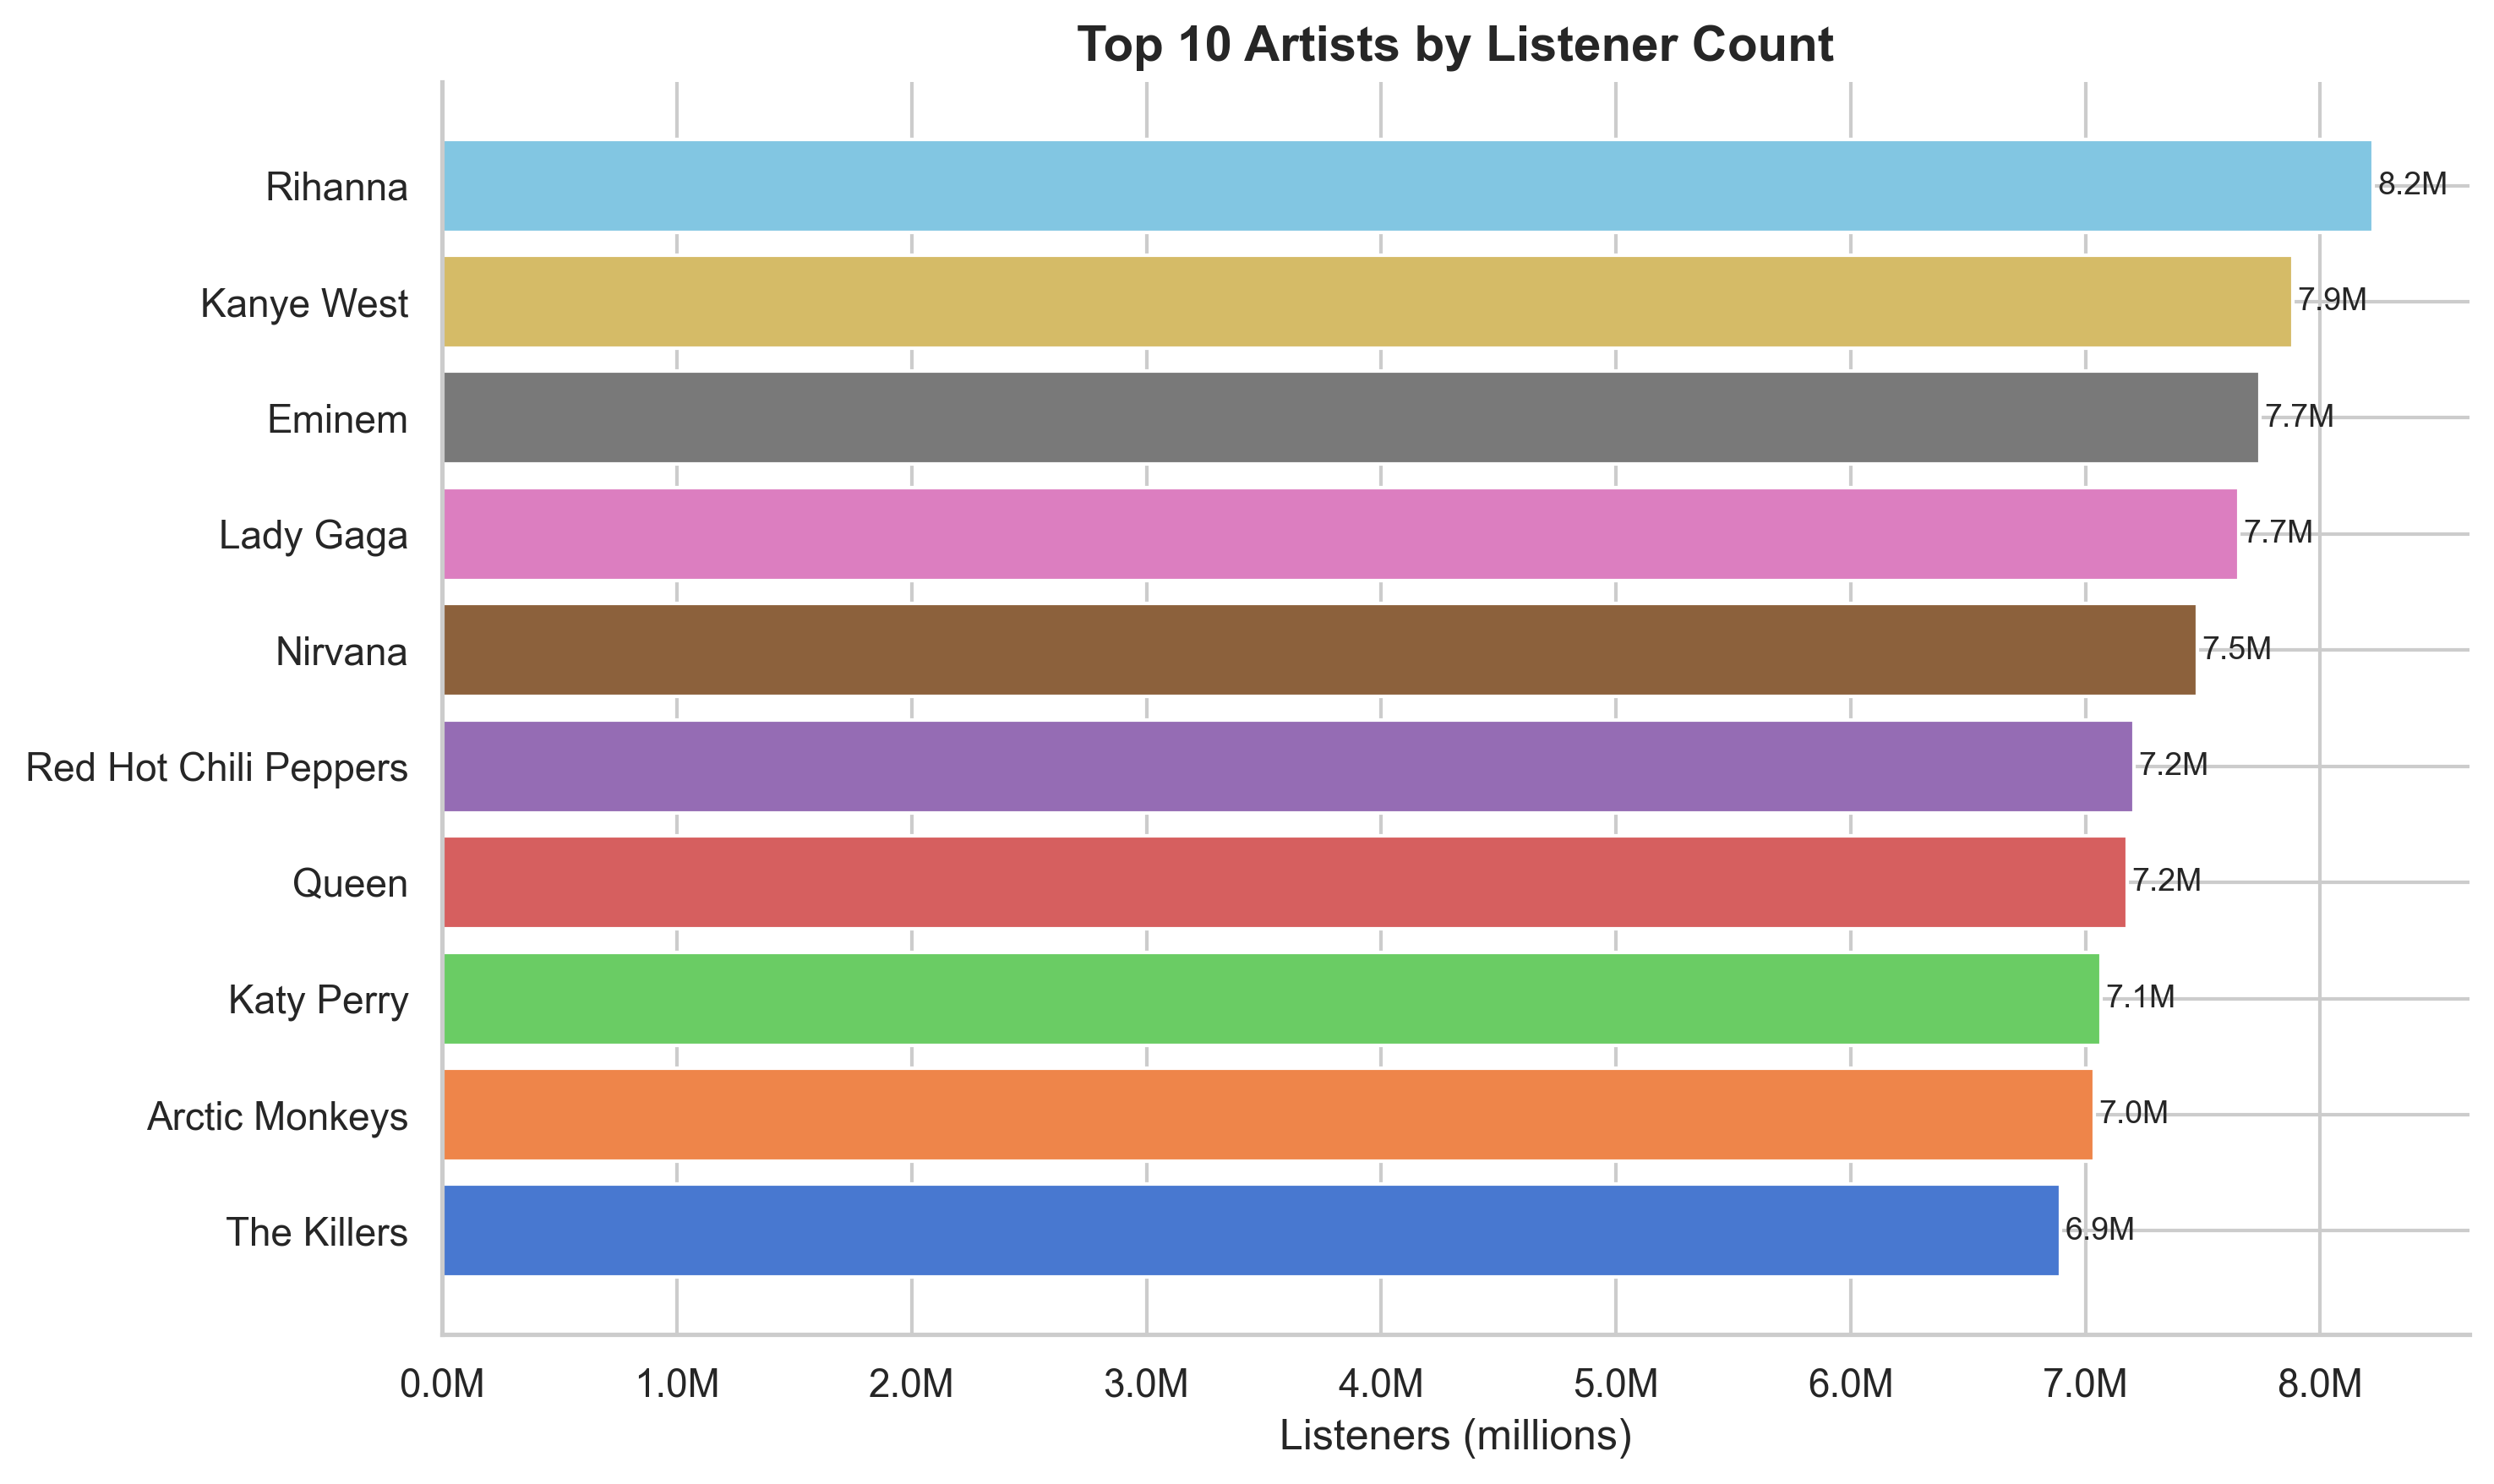

In [5]:
plot_top_artists_by_listeners(df, STATIC_DIR)
from IPython.display import Image
Image(str(STATIC_DIR / 'top_artists_by_listeners.png'))

### Chart 2 – Average Play Count by Data Source (Bar Chart)

**What it shows:** Mean play count for artists from each data source.

**Why bar chart?**  
Bar charts are optimal for comparing discrete categories (data sources) where each bar height encodes a single aggregated value. The y-axis starts at zero to preserve proportional perception.

**Tufte principle:** Axes anchored at zero; no grid inside bars.

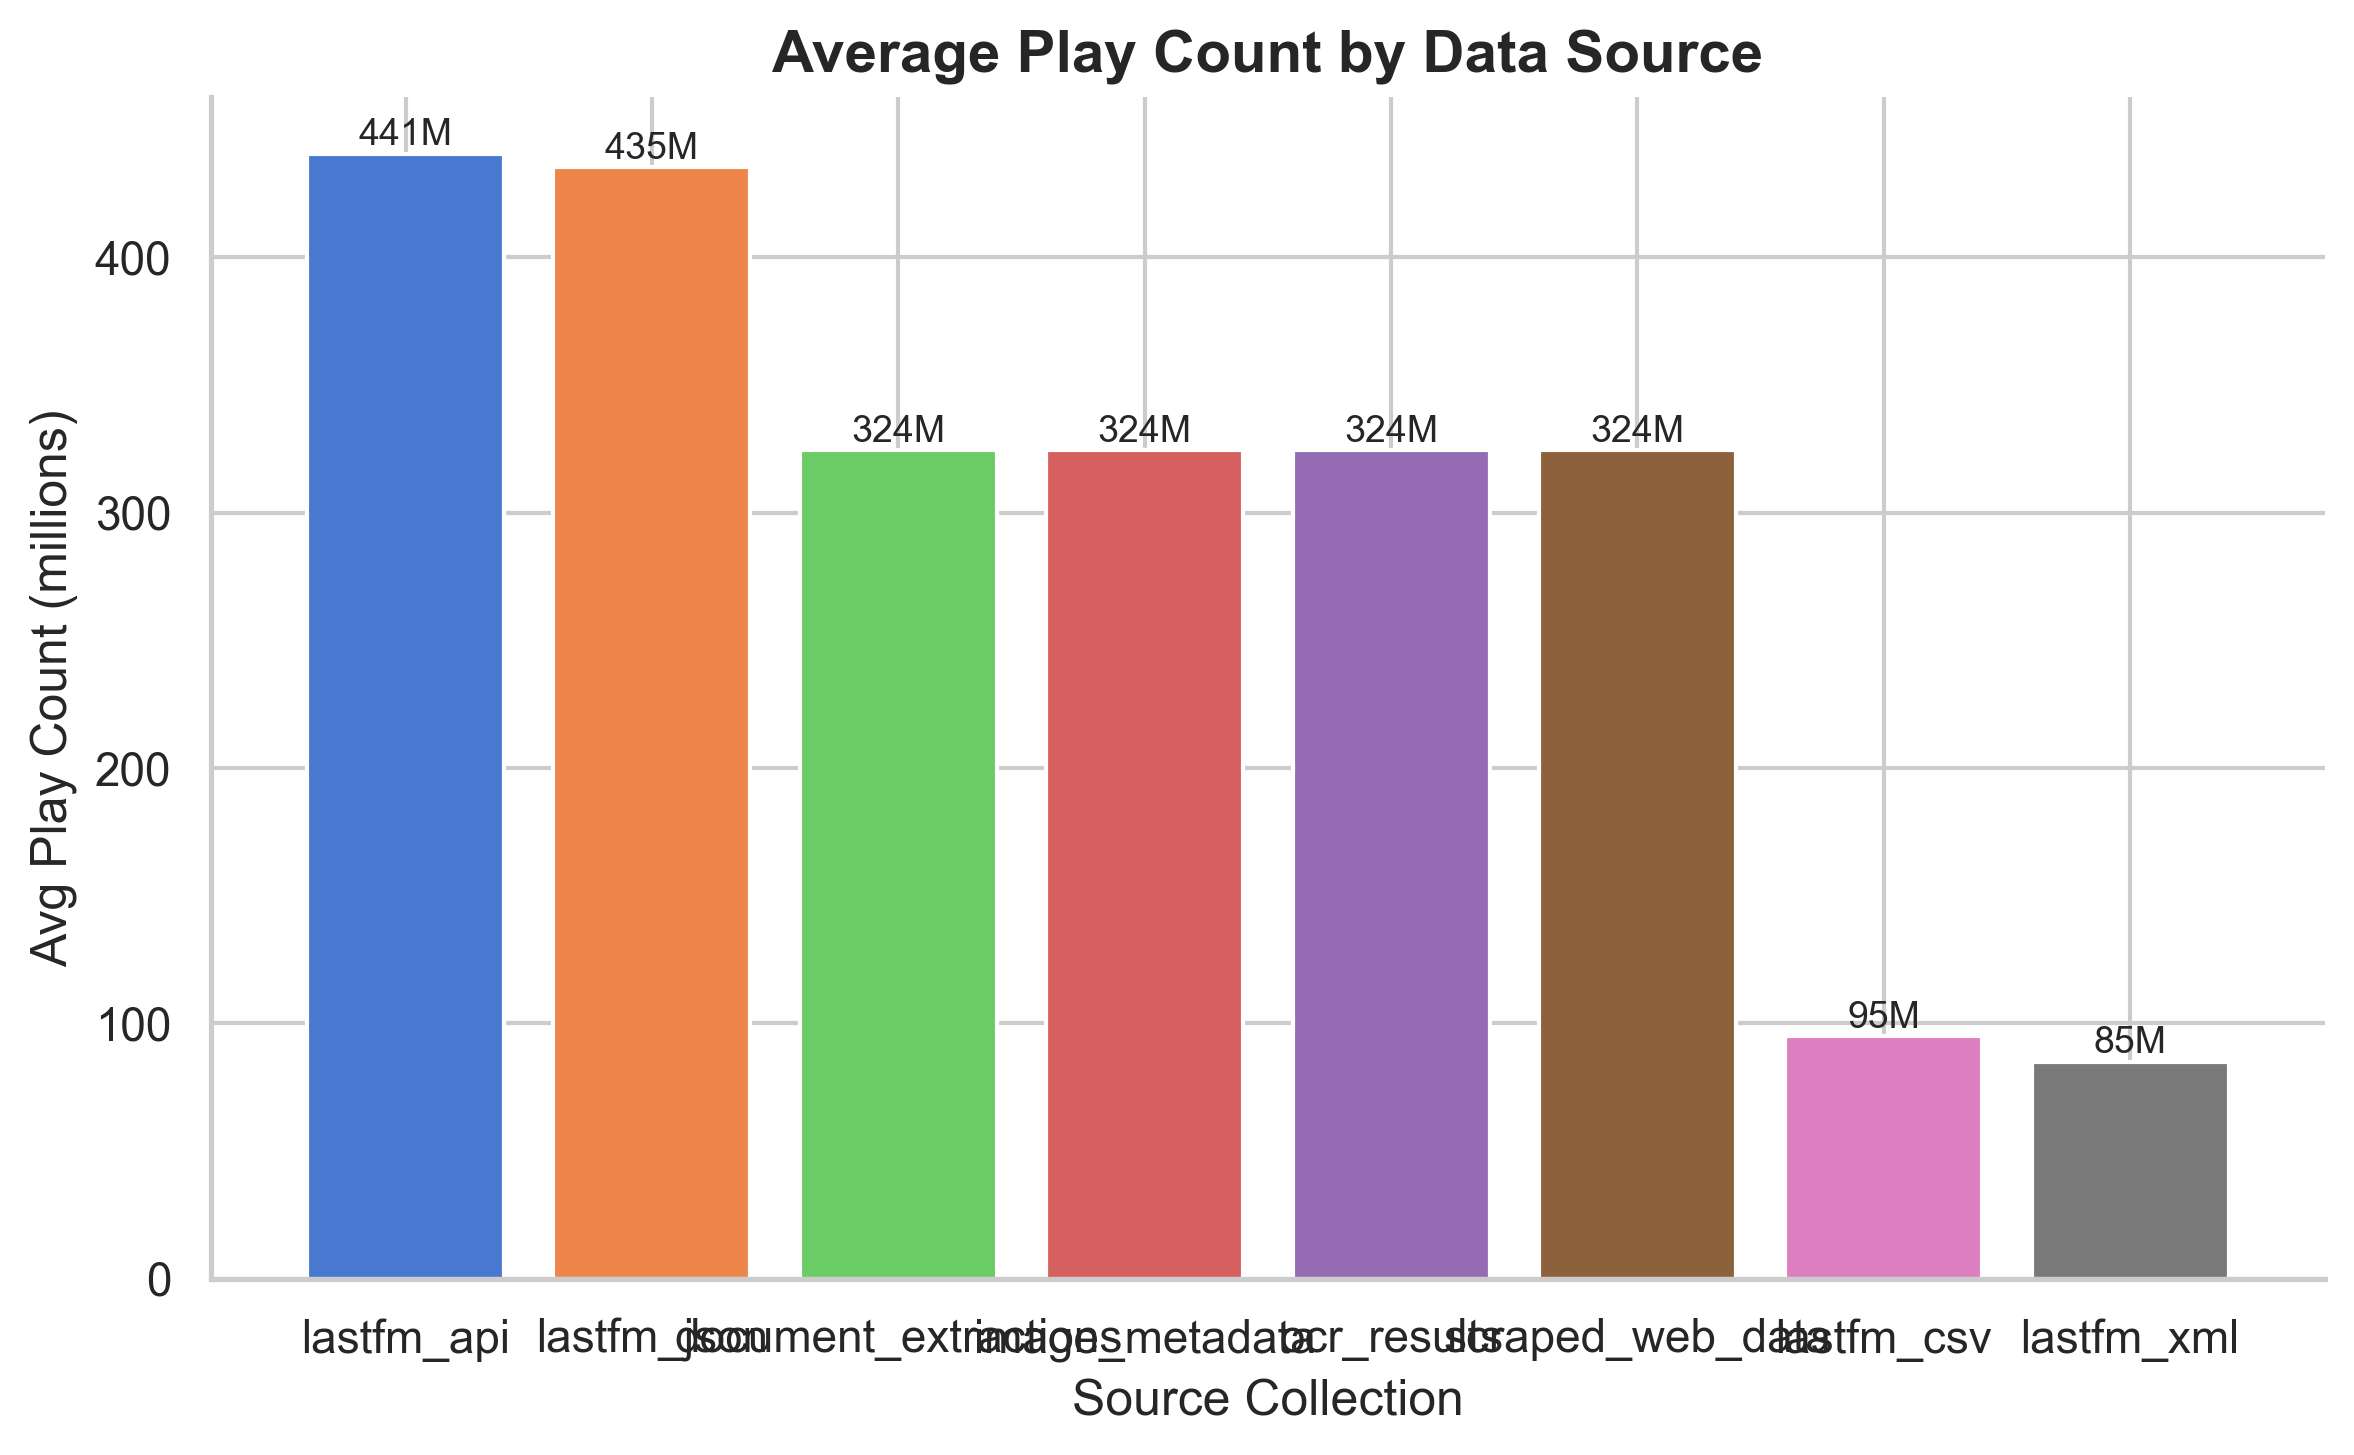

In [6]:
plot_playcount_by_source(df, STATIC_DIR)
Image(str(STATIC_DIR / 'avg_playcount_by_source.png'))

### Chart 3 – Distribution of Listener Counts (Histogram)

**What it shows:** The shape of the listener-count distribution across all artists.

**Why histogram?**  
Histograms are the correct chart for understanding the distribution of a continuous variable — whether it is right-skewed (most artists have few listeners; a few have very many), bimodal, or normal. A bar chart would only show counts per discrete category, not the distributional shape.

**Encoding decisions:** KDE overlay makes the underlying density visible without adding chartjunk. Bins encode frequency directly.

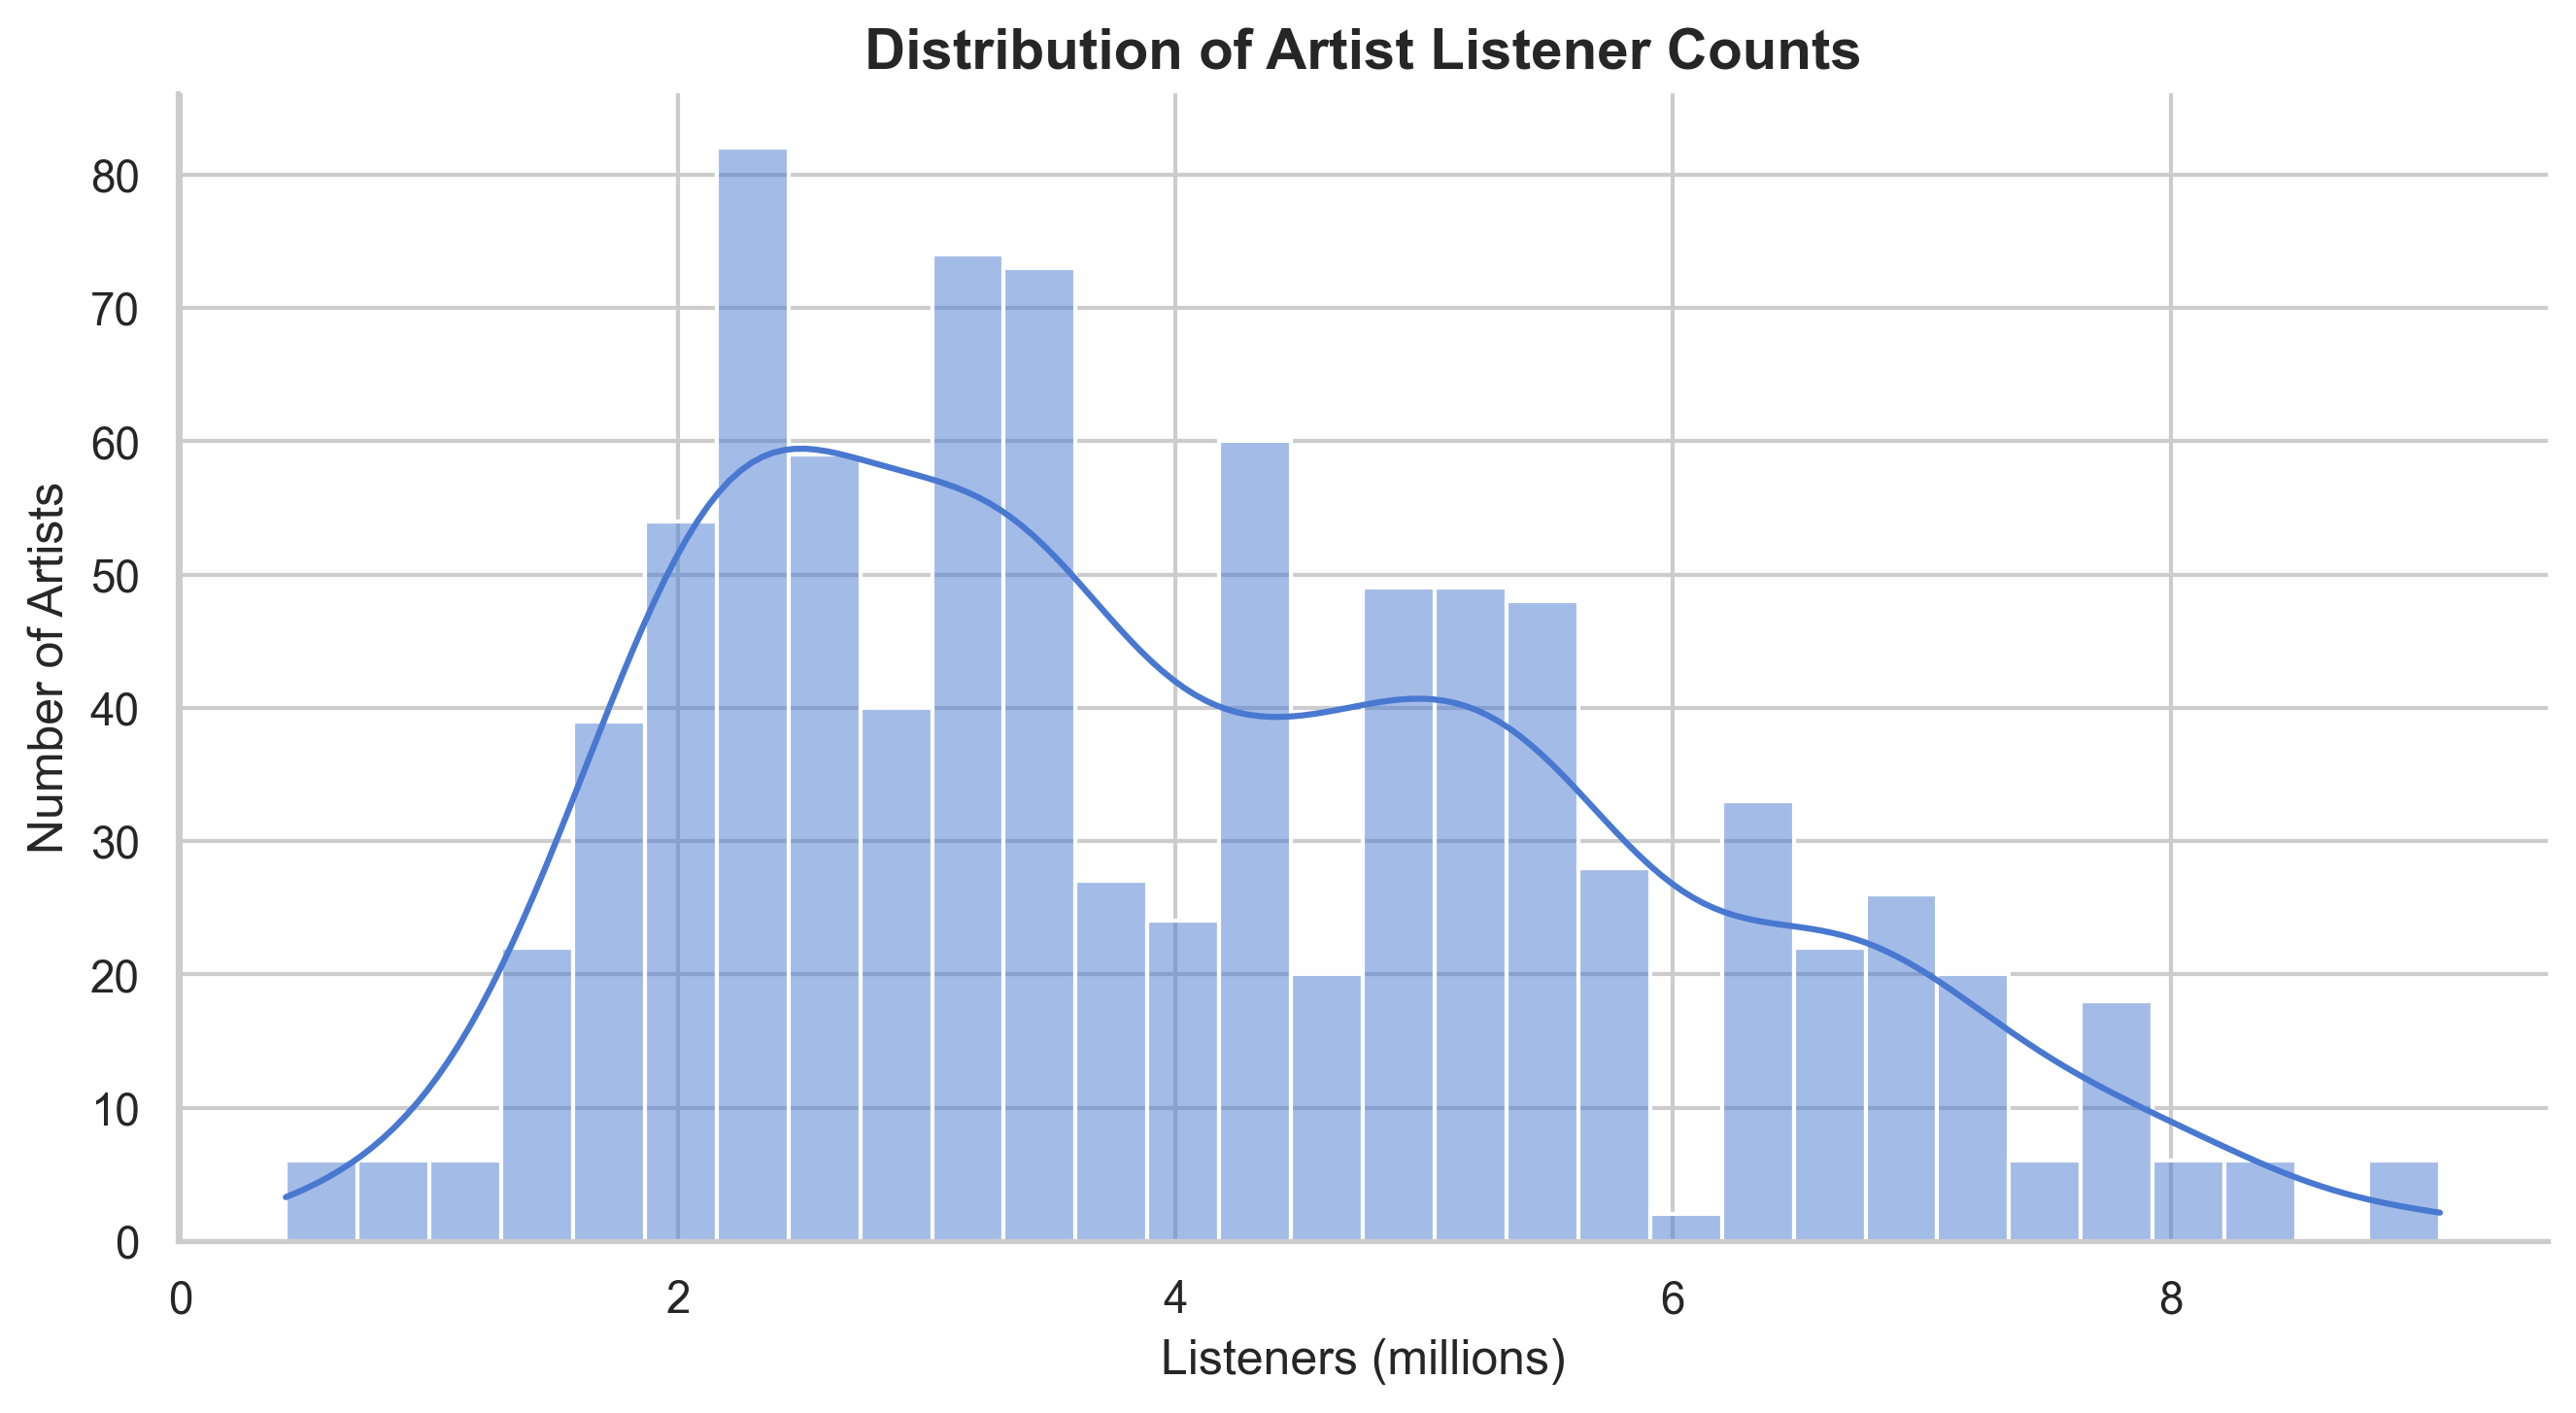

In [7]:
plot_listeners_distribution(df, STATIC_DIR)
Image(str(STATIC_DIR / 'listeners_distribution.png'))

### Chart 4 – Distribution of Play Counts (Histogram)

**What it shows:** The shape of the play-count distribution across all artists.

**Why histogram?**  
A second histogram on play count lets us compare its distributional shape against listeners. If the distributions mirror each other, it suggests proportional engagement; divergence reveals replay behaviour (some artists have high listens but low plays, or vice versa).

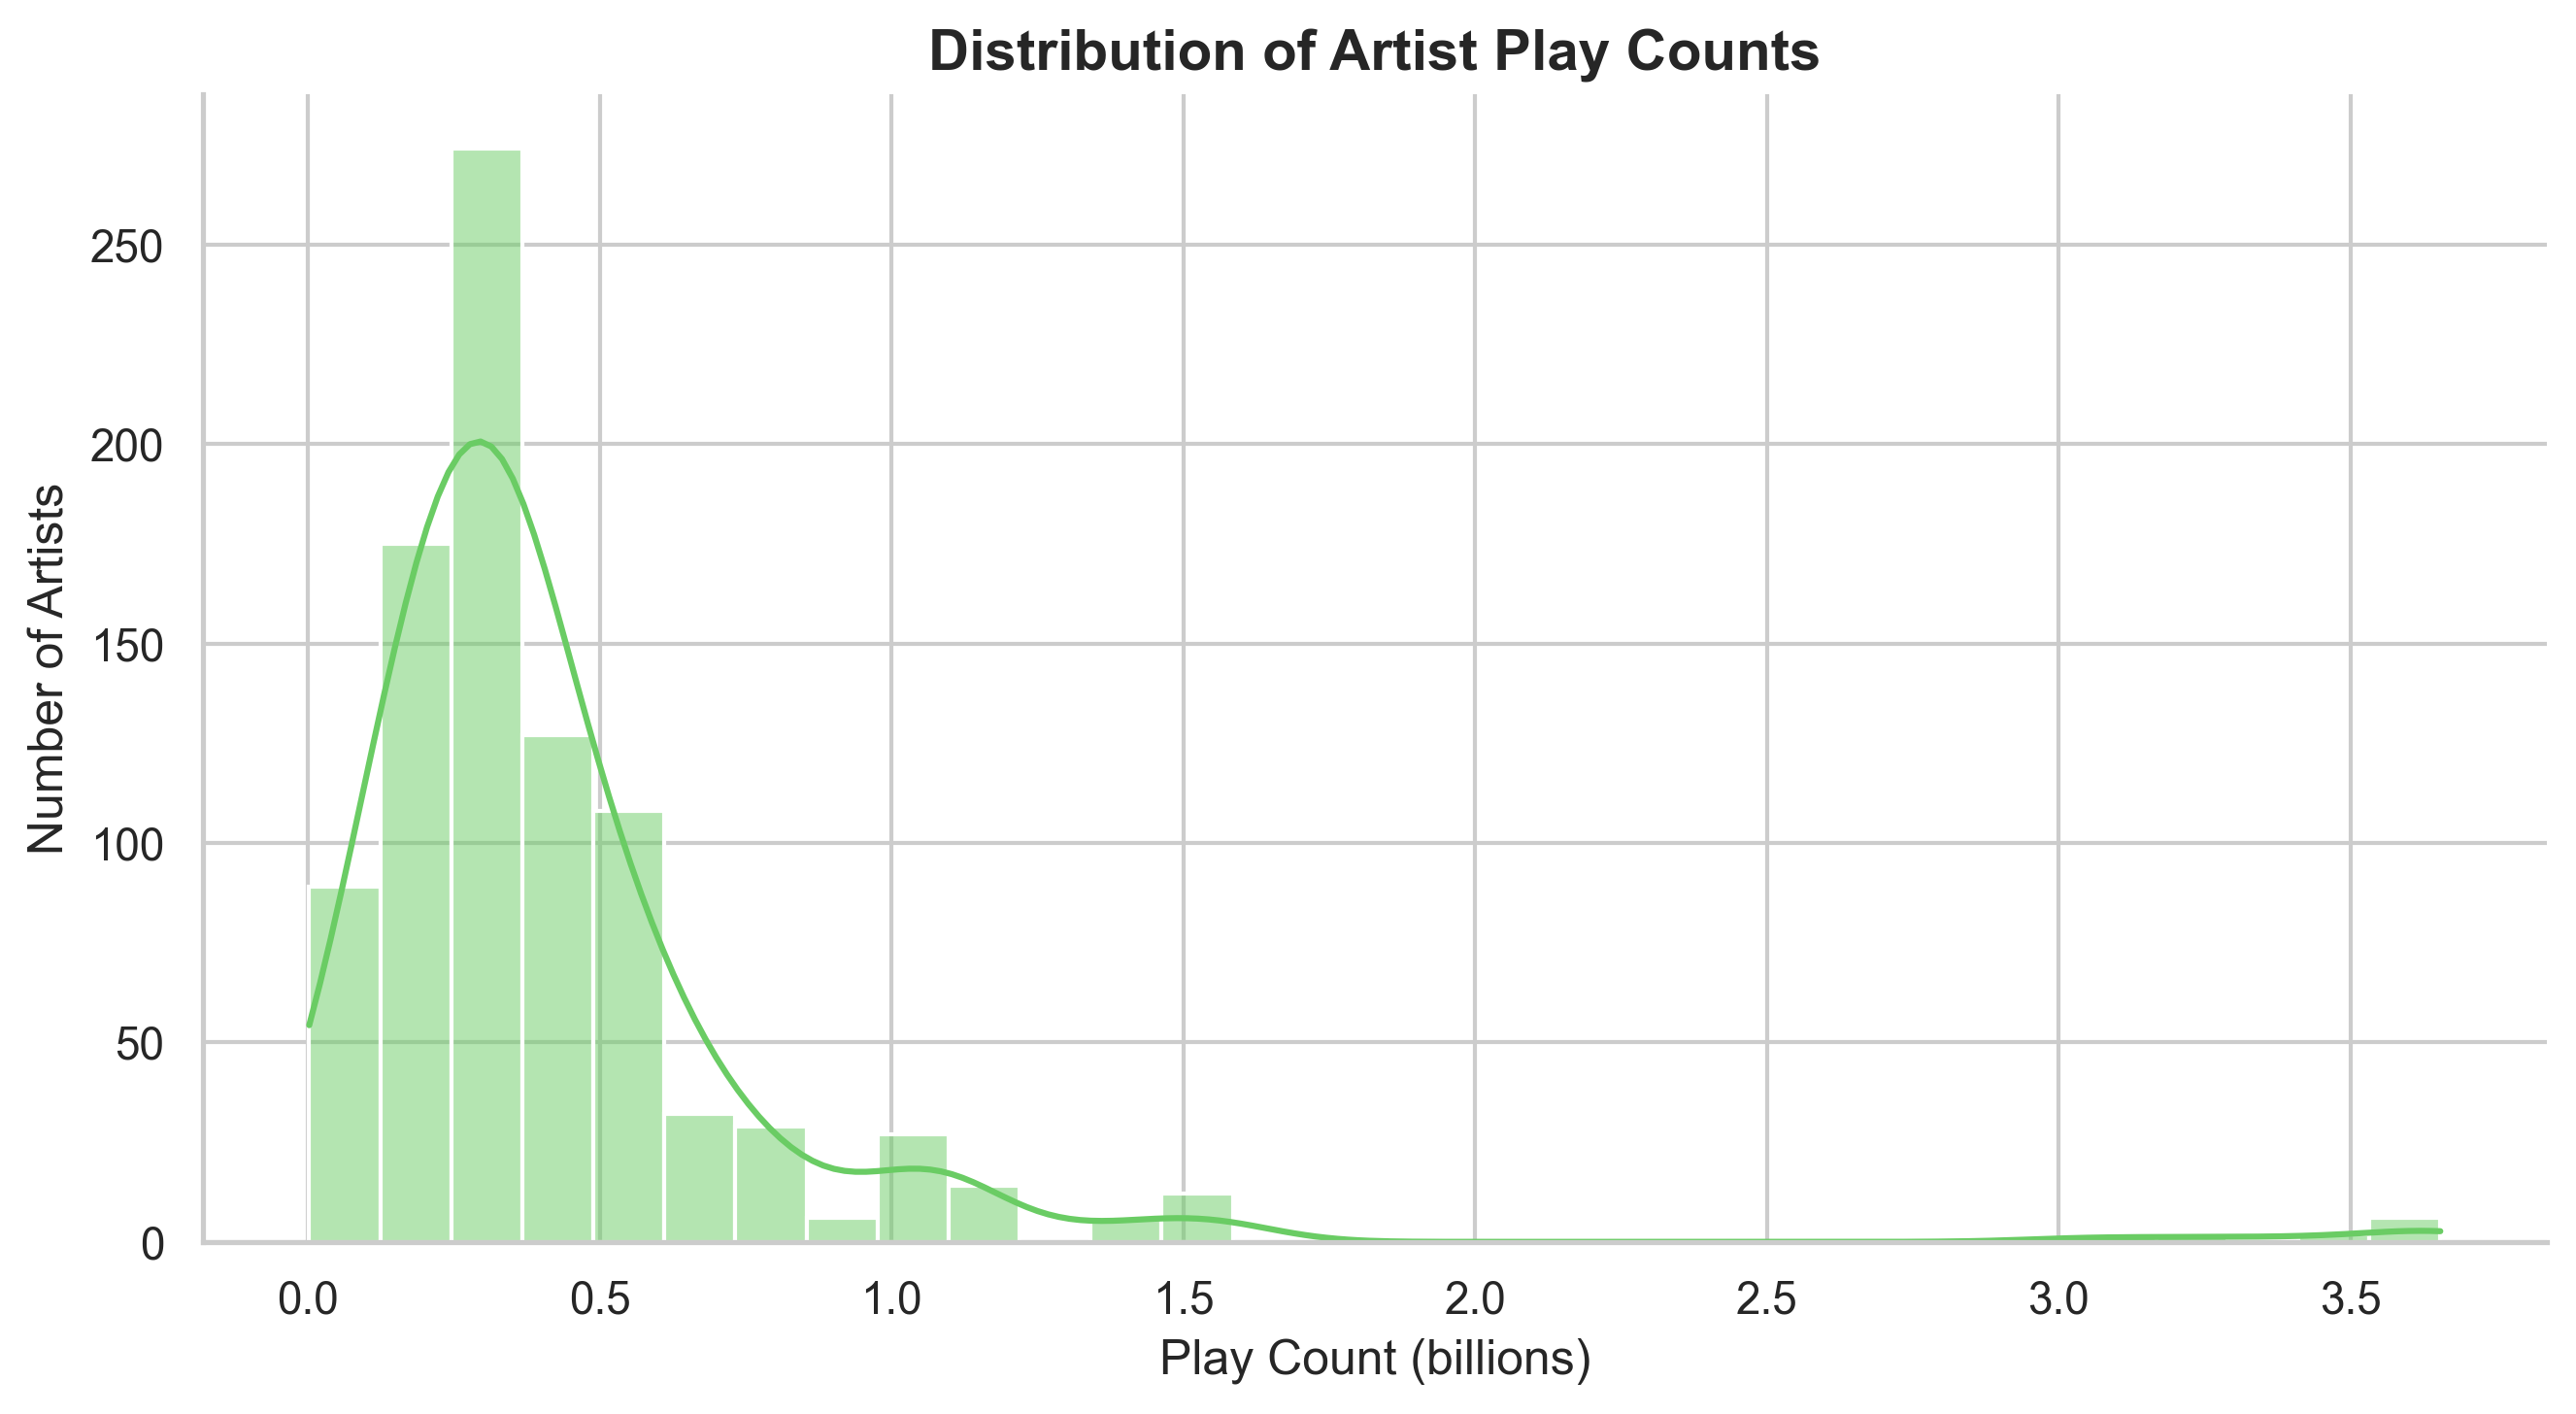

In [8]:
plot_playcount_distribution(df, STATIC_DIR)
Image(str(STATIC_DIR / 'playcount_distribution.png'))

### Chart 5 – Listener Distribution by Source (Box Plot)

**What it shows:** The spread, median, IQR, and outliers of listener counts grouped by data source.

**Why box plot?**  
Box plots compare distributions across categories by showing five summary statistics (min, Q1, median, Q3, max) plus outliers. A simple bar chart showing only the mean would hide skew and variance within each source. This is the correct choice when comparing distributions across groups.

**Tufte principle:** Whiskers and box carry five statistics in minimal ink.

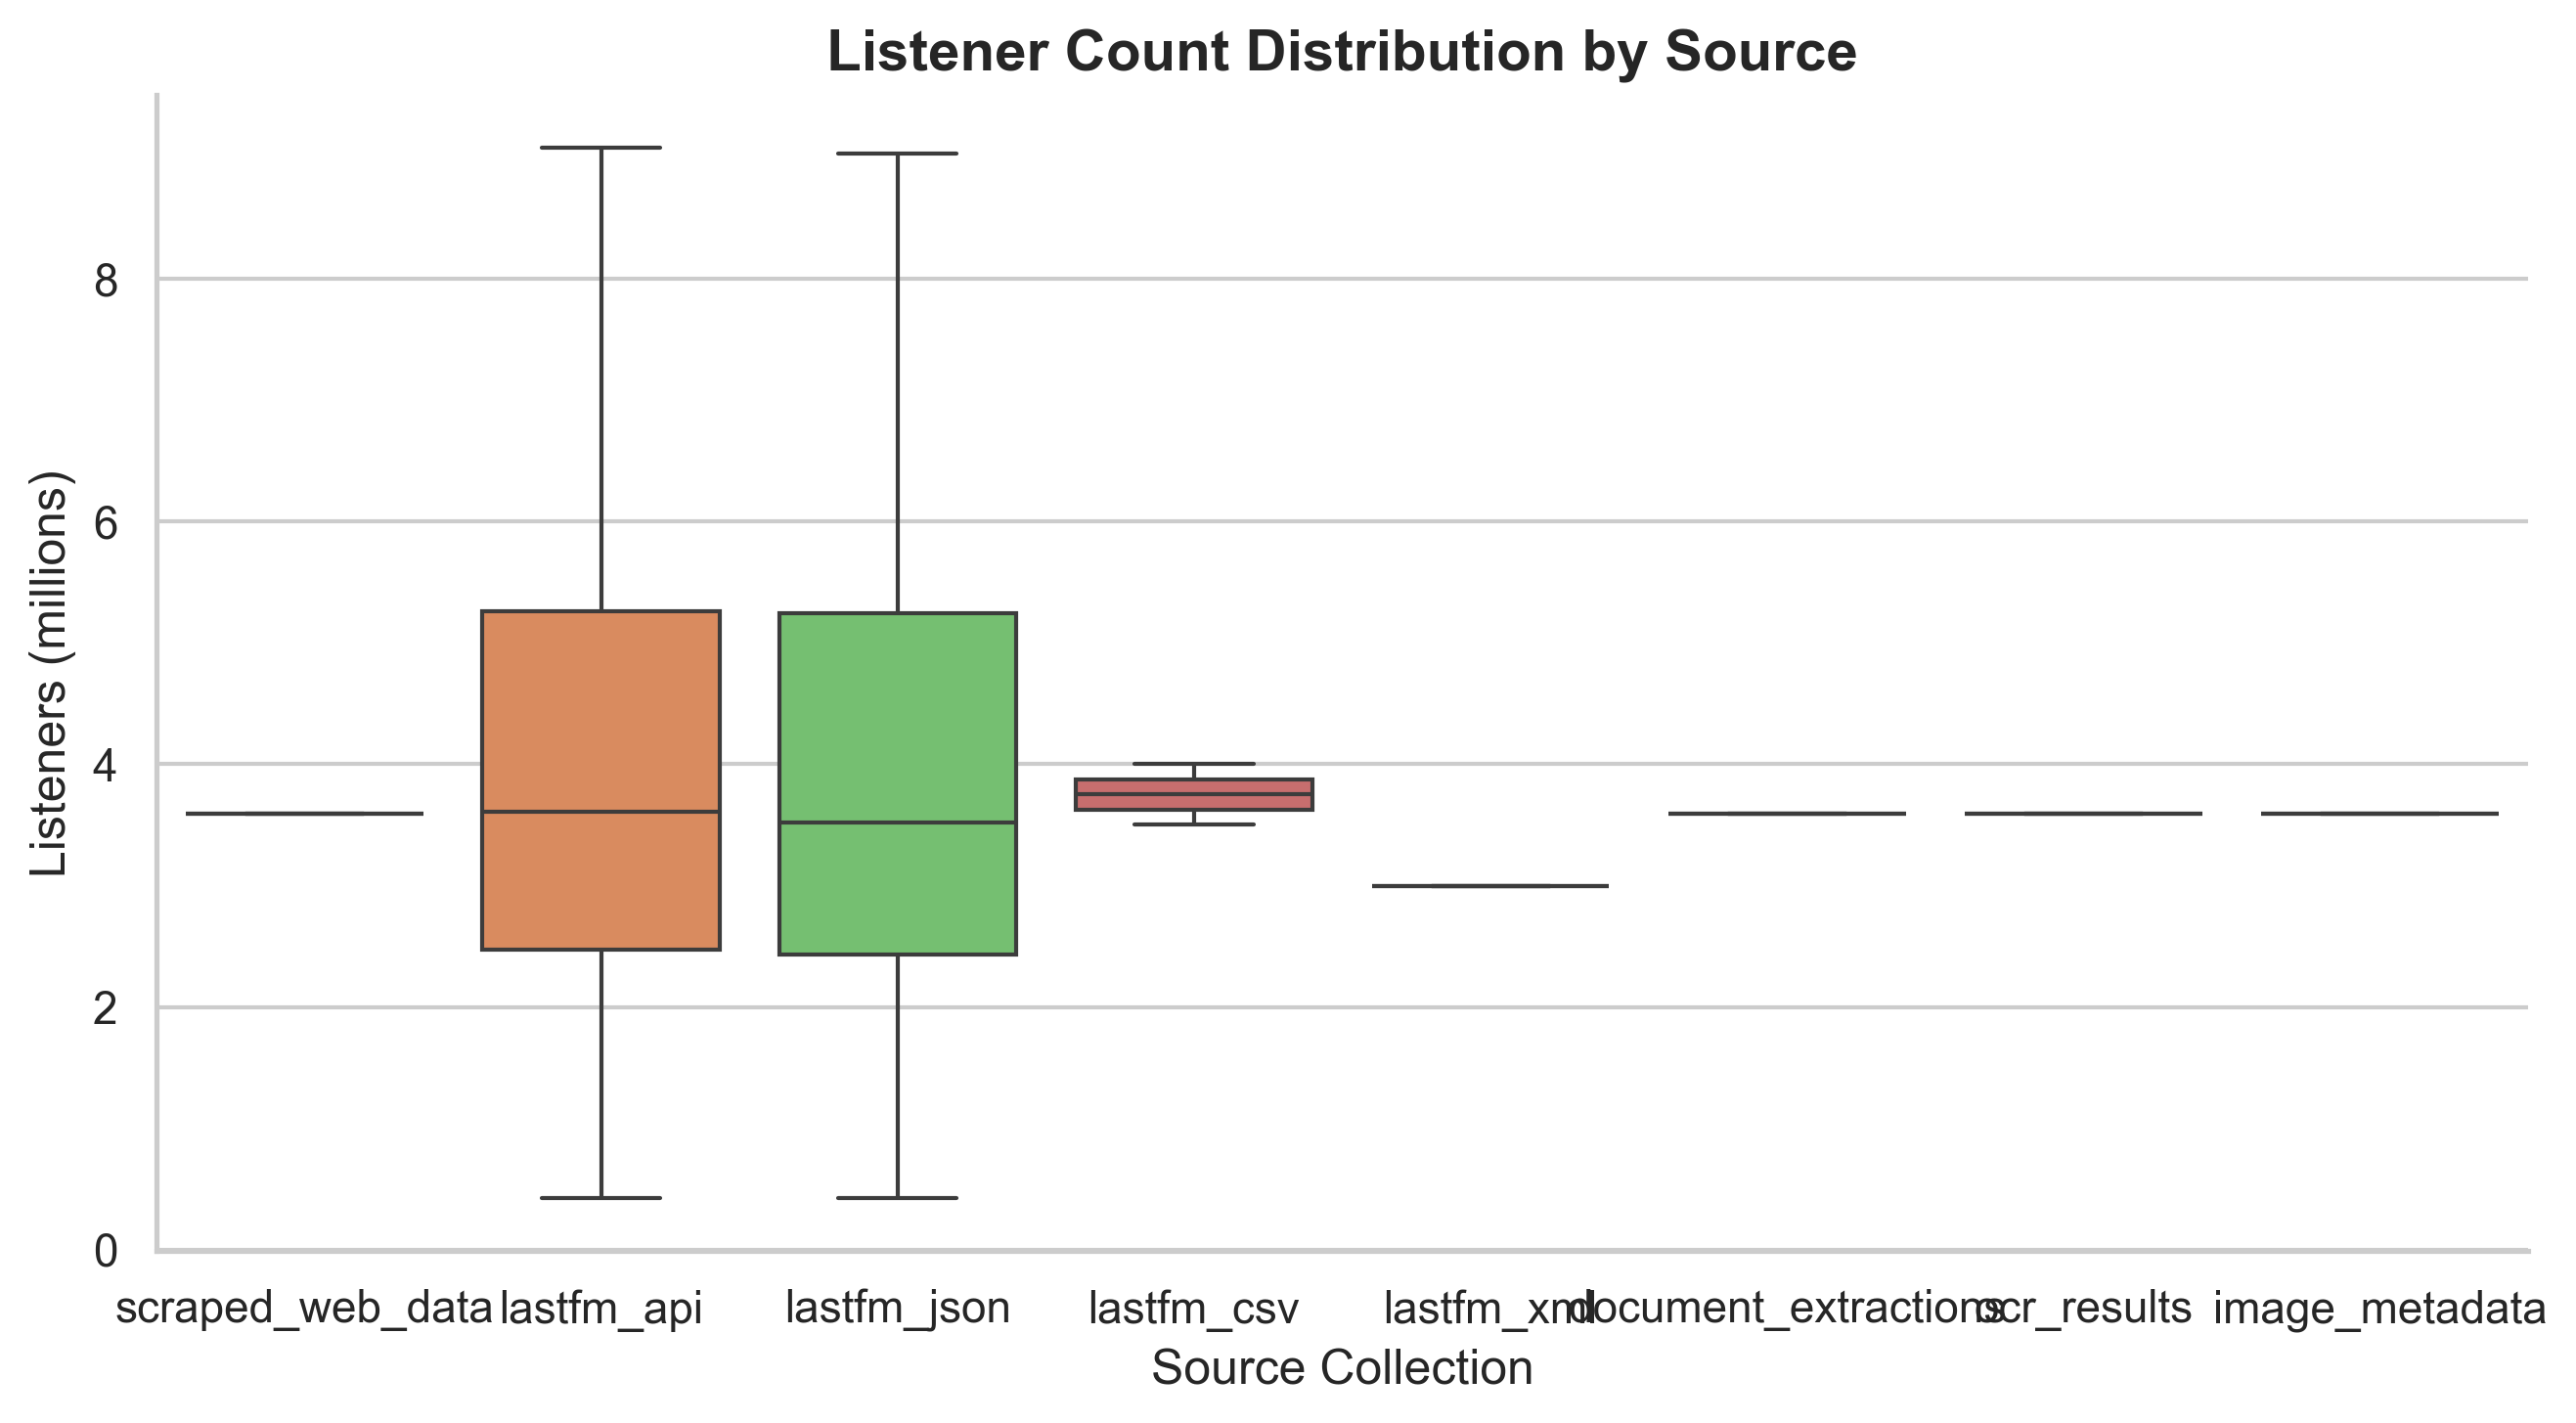

In [9]:
plot_listeners_boxplot_by_source(df, STATIC_DIR)
Image(str(STATIC_DIR / 'listeners_boxplot_by_source.png'))

### Chart 6 – Listeners vs Play Count (Scatter Plot)

**What it shows:** The relationship between listener count and play count, coloured by data source.

**Why scatter plot?**  
Scatter plots reveal the relationship (and correlation) between two continuous variables. Colour encodes a third dimension (source) without distorting the x/y position encoding. We can visually detect whether listeners and play count are linearly correlated, clustered by source, or independent.

**Encoding decisions:** Transparency (`alpha=0.7`) reduces overplotting; white edge lines separate overlapping points.

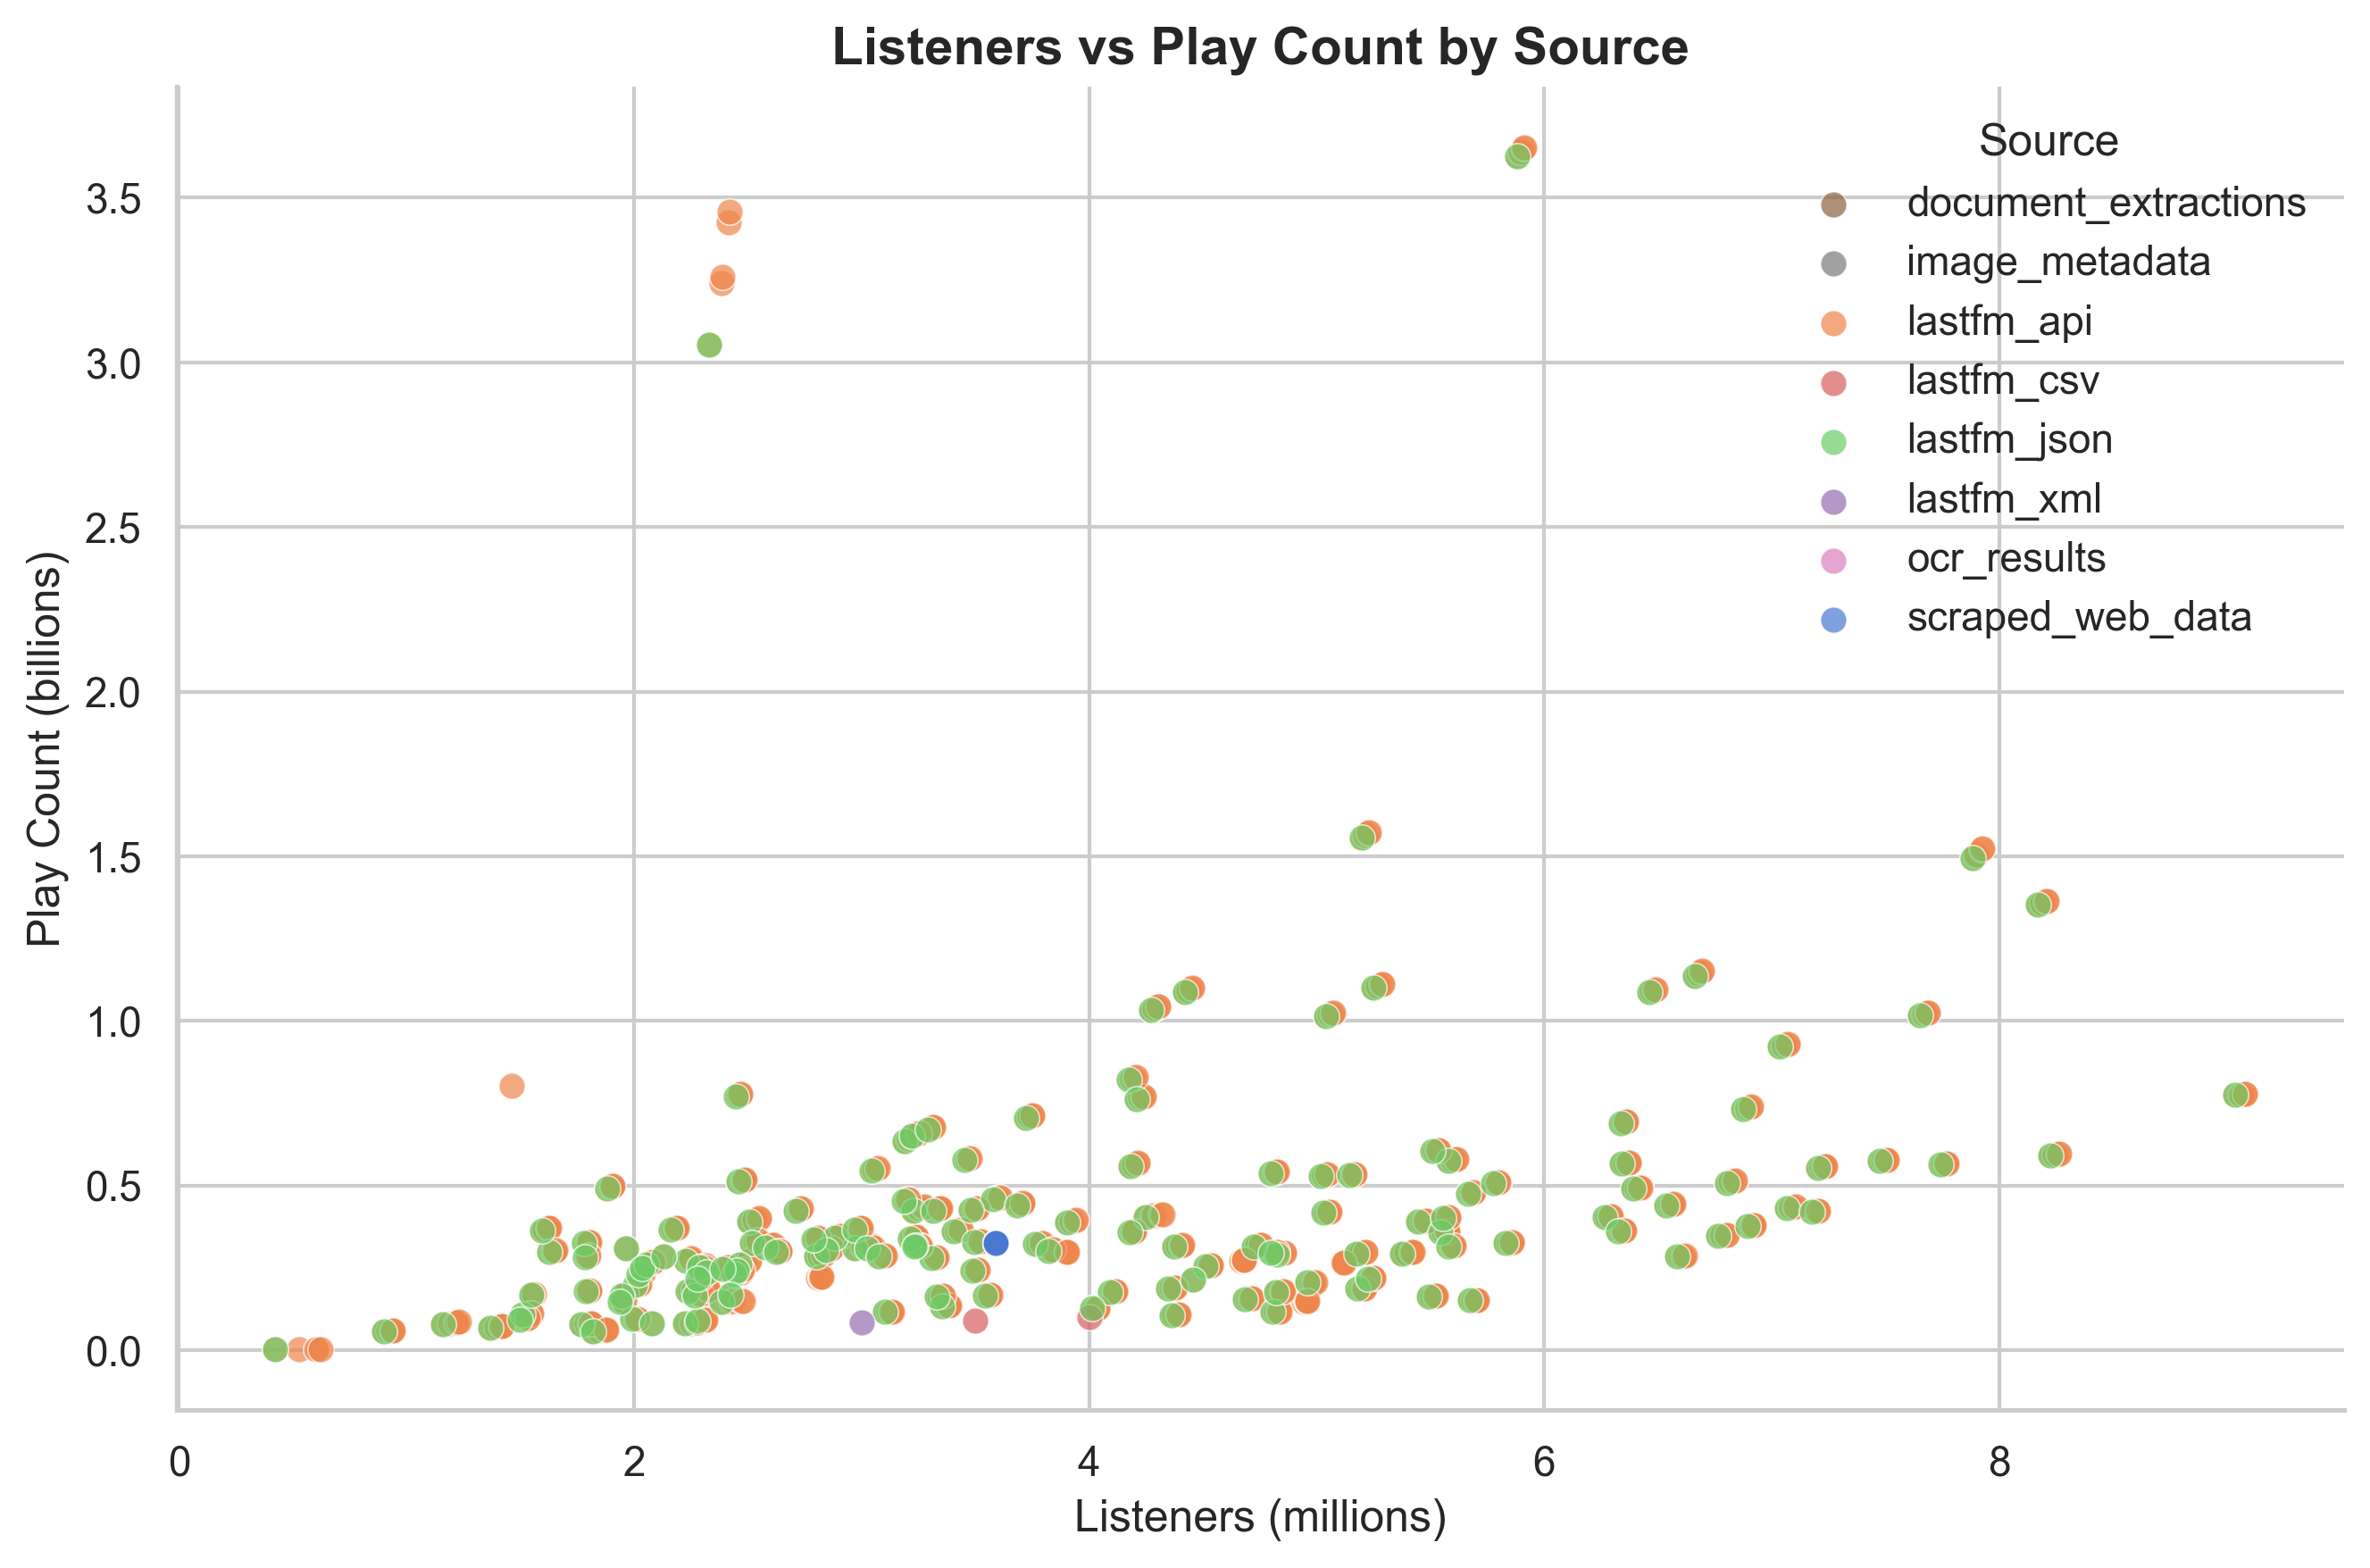

In [10]:
plot_listeners_vs_playcount_scatter(df, STATIC_DIR)
Image(str(STATIC_DIR / 'listeners_vs_playcount_scatter.png'))

### Chart 7 – Correlation Heatmap

**What it shows:** The pairwise Pearson correlation matrix for all numeric features.

**Why heatmap?**  
A heatmap is the canonical visualization for pairwise correlation matrices. Colour encodes the coefficient on a diverging scale (blue = negative, white = zero, red = positive), making strong relationships immediately visible without having to read numbers. A table of correlation coefficients would convey the same information far less efficiently.

**Encoding decisions:** Annotations inside cells eliminate the need to look up a separate colour bar.

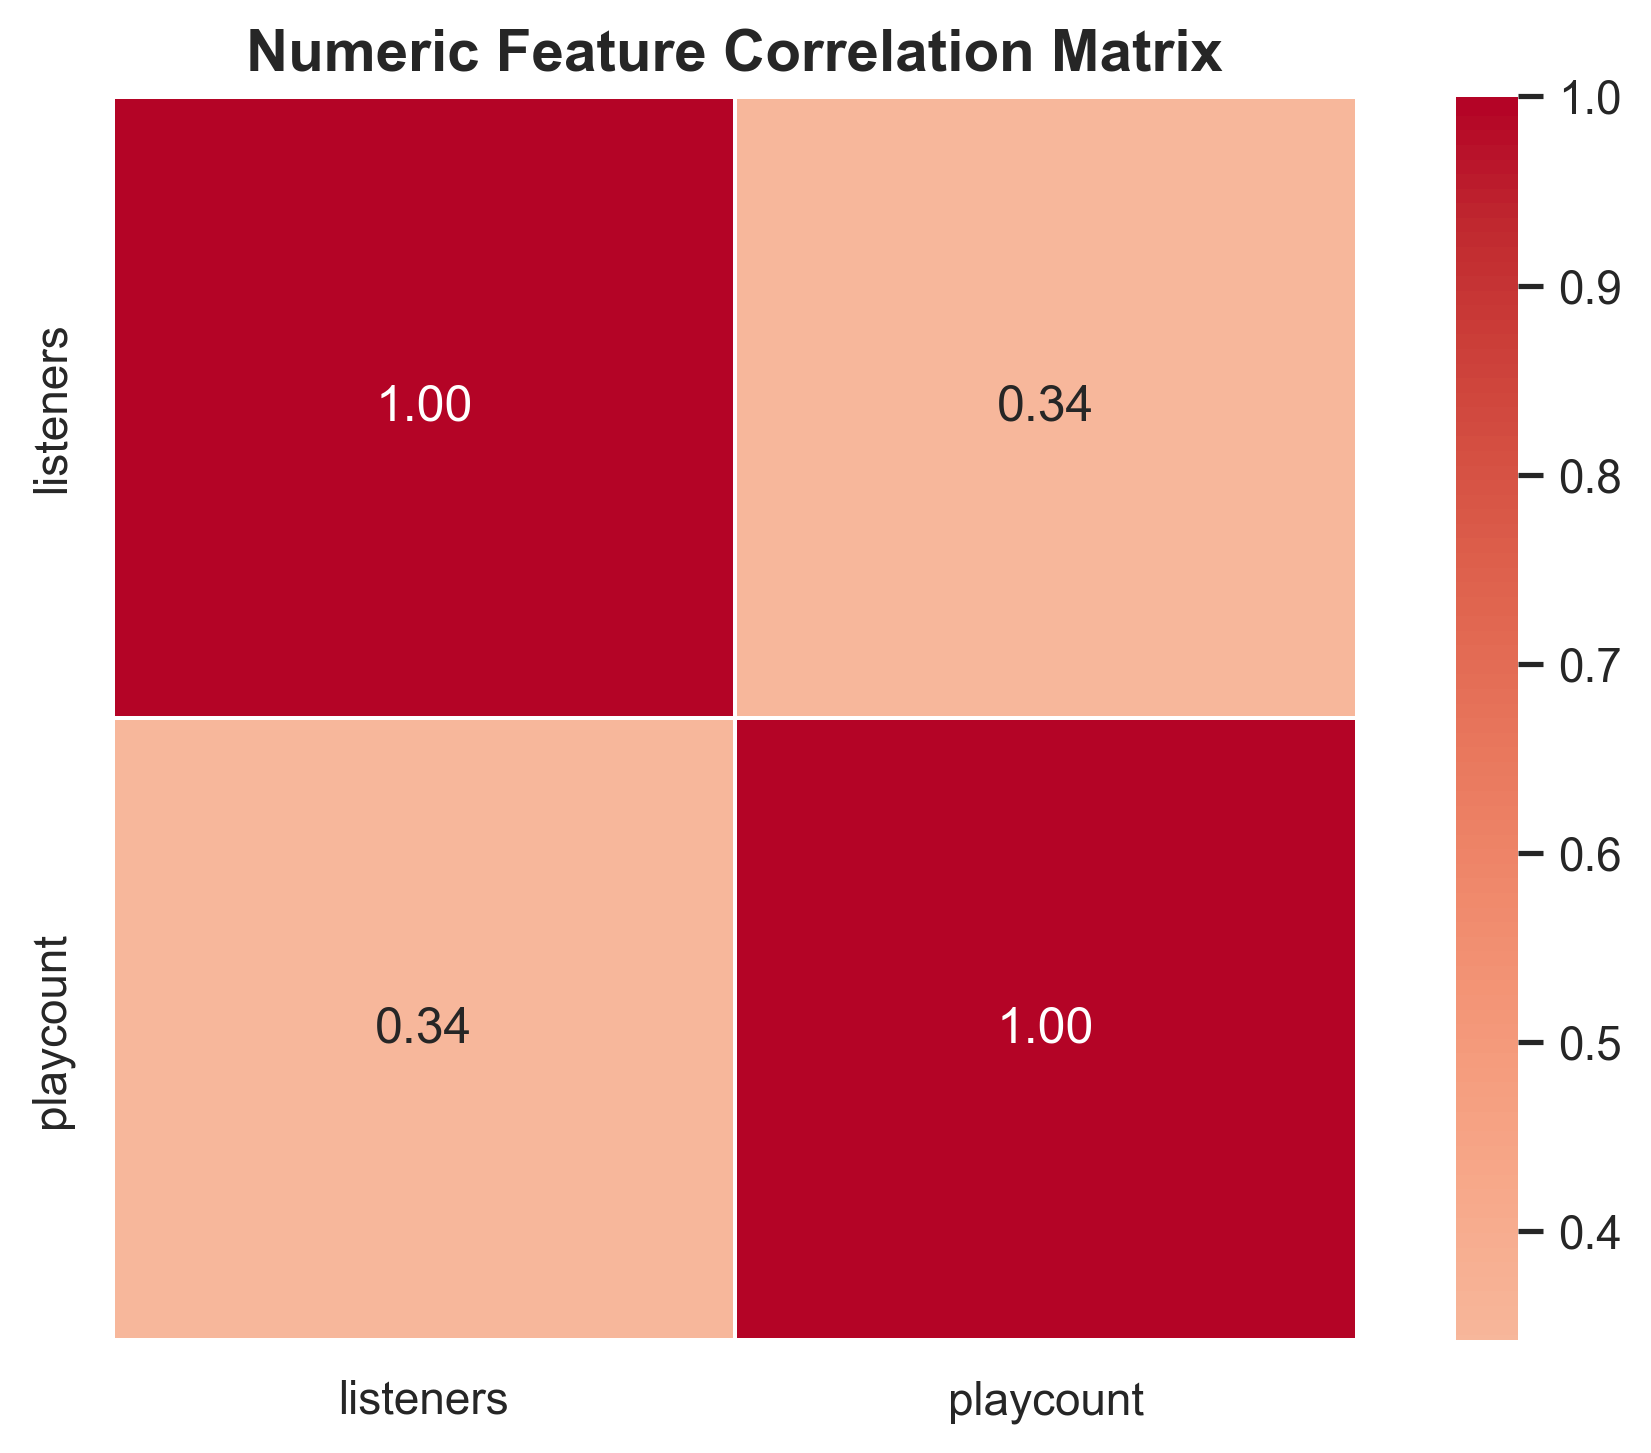

In [11]:
plot_correlation_heatmap(df, STATIC_DIR)
Image(str(STATIC_DIR / 'correlation_heatmap.png'))

### Chart 8 – 2×2 Dashboard (Multi-Panel Layout)

**What it shows:** Four panels on one canvas: top-10 bar, listener distribution, scatter, and boxplot.

**Why multi-panel?**  
A 2×2 layout lets a single shareable image tell the whole story — useful for executive dashboards where recipients need an overview without opening multiple files. `plt.subplots(2, 2)` creates the grid; each panel uses the chart type that best fits its data characteristic.

**Tufte principle:** Consistent seaborn theme across all panels; shared figure title anchors the narrative.

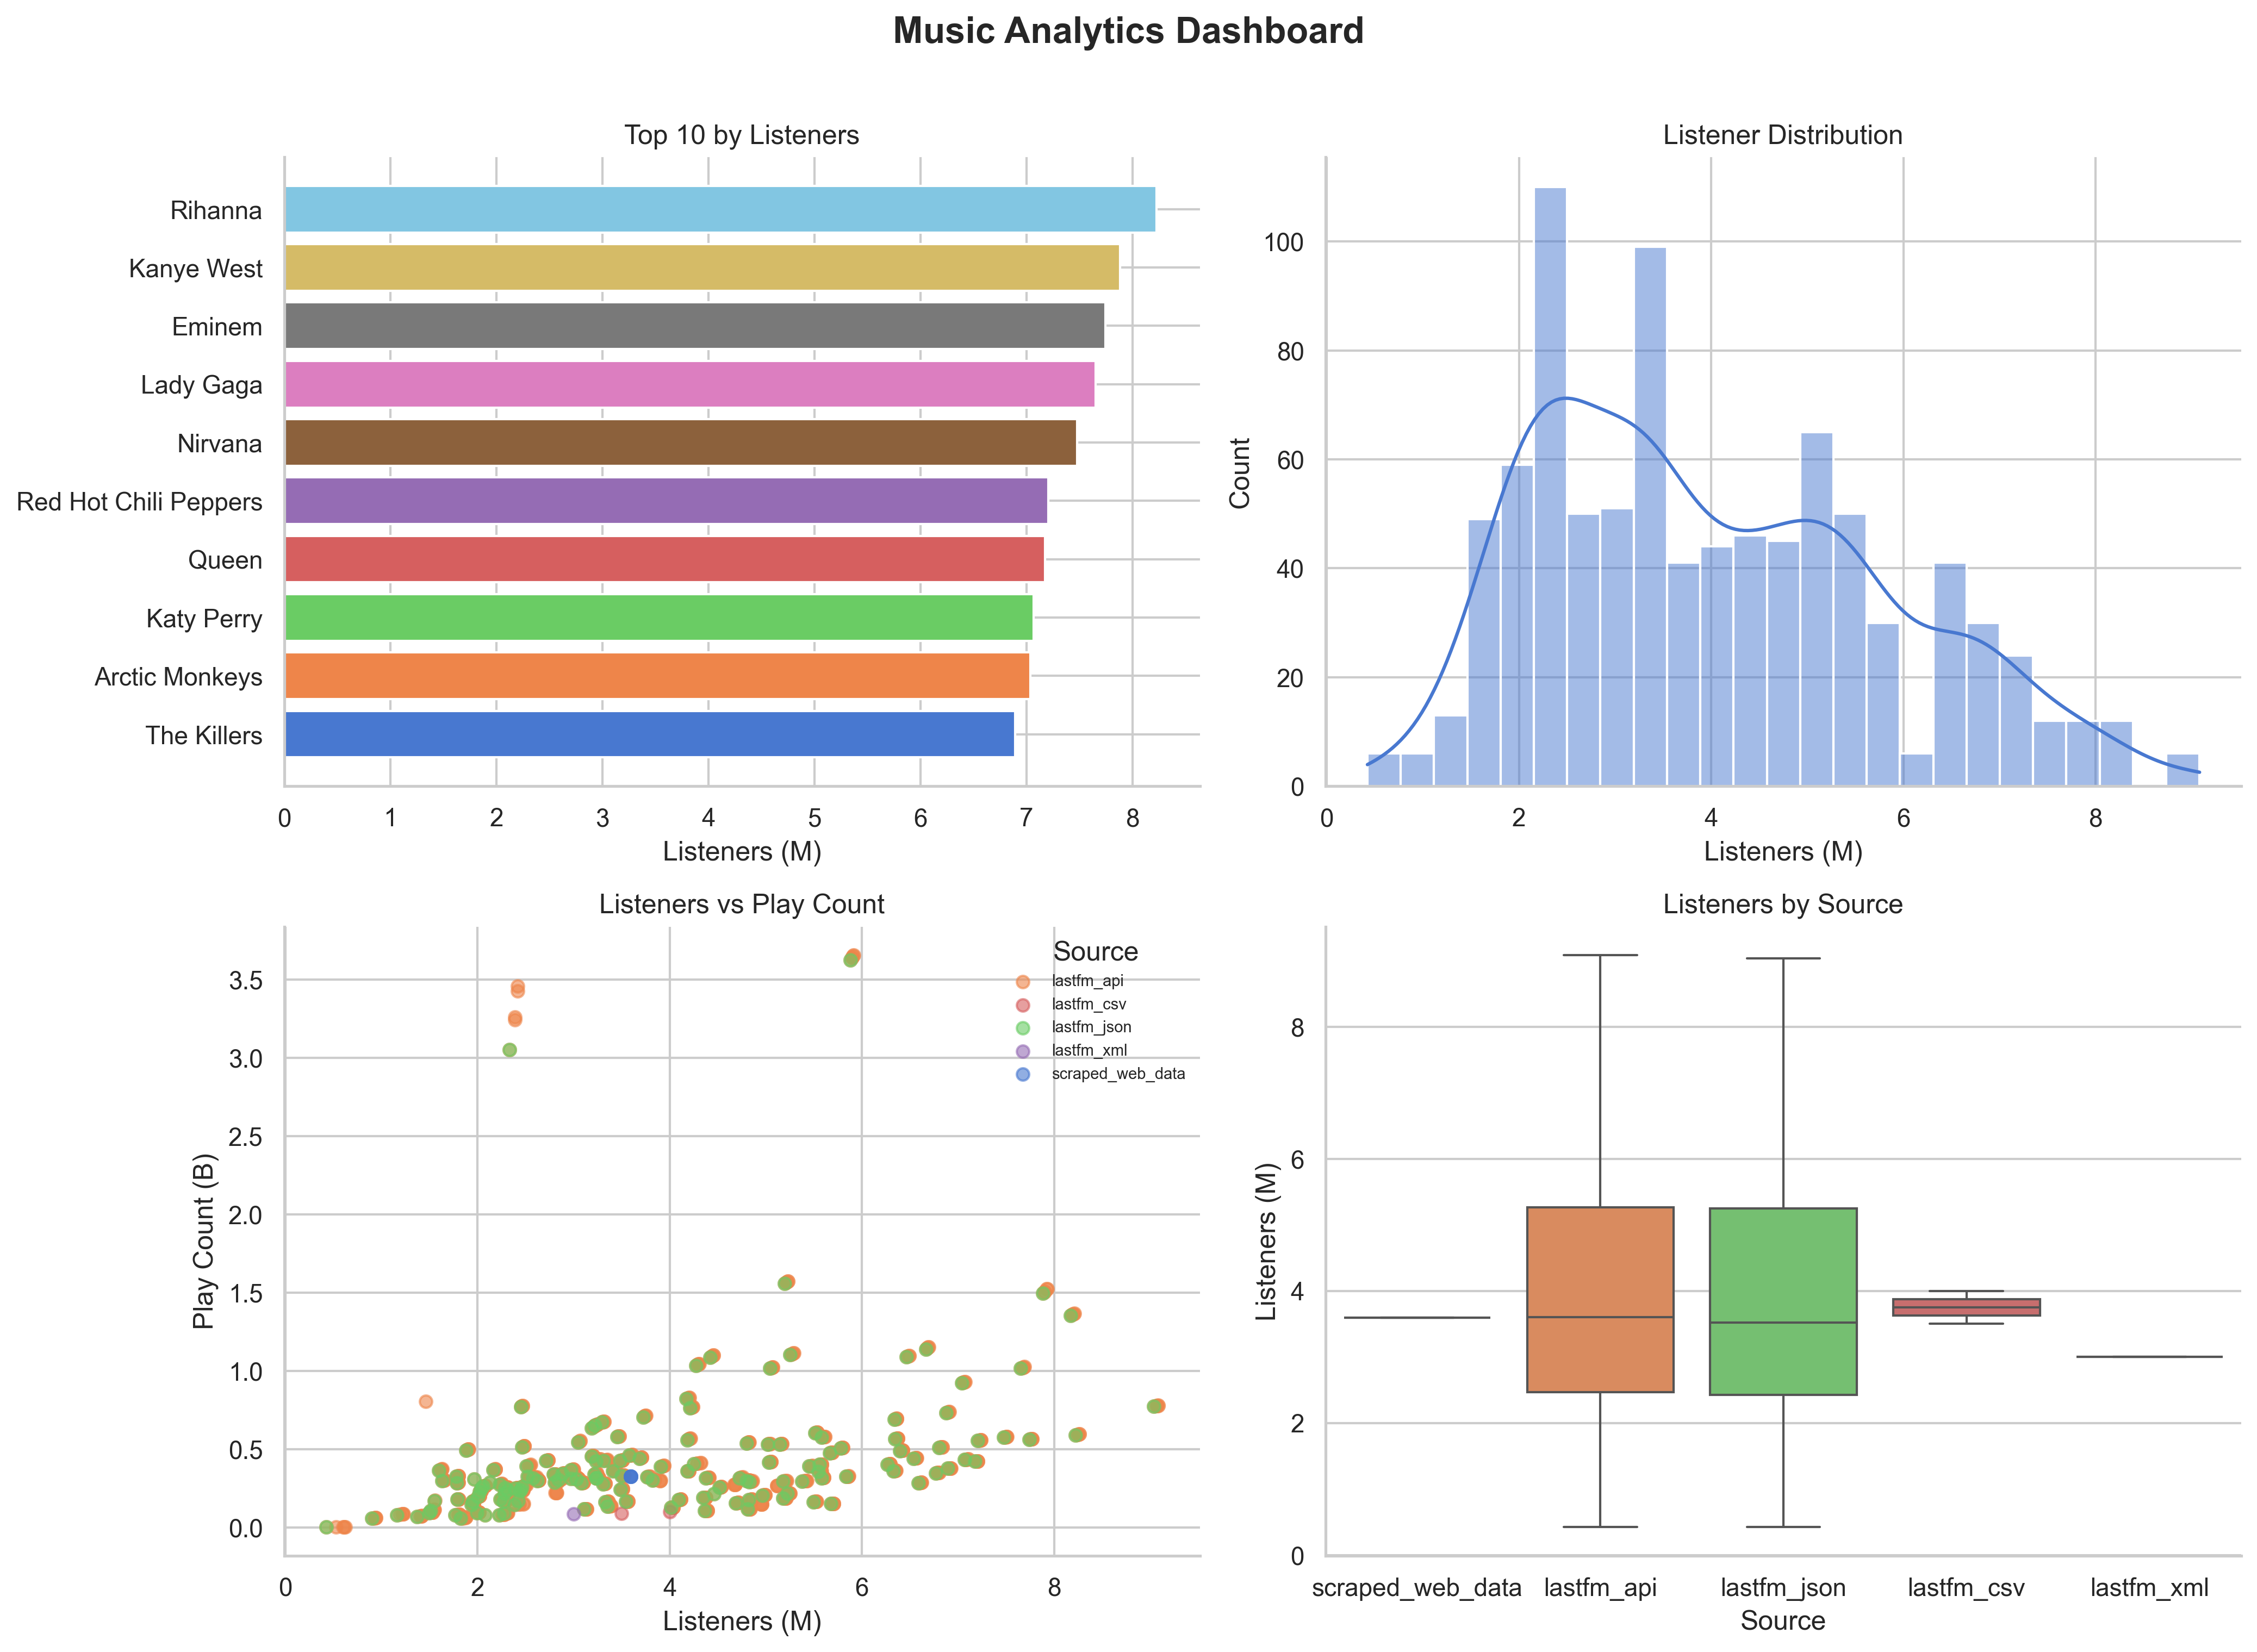

In [12]:
plot_dashboard_subplots(df, STATIC_DIR)
Image(str(STATIC_DIR / 'dashboard_subplots.png'))

In [13]:
# Verify all 8 PNG files were created
pngs = list(STATIC_DIR.glob('*.png'))
pdfs = list(STATIC_DIR.glob('*.pdf'))
print(f'PNG files: {len(pngs)}')
print(f'PDF files: {len(pdfs)}')
for p in sorted(pngs):
    print(' ', p.name)

PNG files: 8
PDF files: 8
  avg_playcount_by_source.png
  correlation_heatmap.png
  dashboard_subplots.png
  listeners_boxplot_by_source.png
  listeners_distribution.png
  listeners_vs_playcount_scatter.png
  playcount_distribution.png
  top_artists_by_listeners.png


---
## Part 3 – Interactive Charts with Plotly

All interactive charts are saved as **self-contained HTML files** under `outputs/visualizations/interactive/`.  
Open any HTML file directly in a browser — no server required.  
In this notebook, `fig.show()` renders charts inline via the Plotly renderer.

In [14]:
import plotly.io as pio
pio.renderers.default = 'notebook_connected'

from visualization.interactive_charts import (
    interactive_top_artists_bar,
    interactive_scatter_listeners_playcount,
    interactive_source_breakdown_pie,
    interactive_listeners_histogram,
    interactive_multi_layout,
)
print('Interactive chart functions imported.')

Interactive chart functions imported.


### Interactive Chart 1 – Top 20 Artists by Listeners (Interactive Bar)

**What it shows:** The 20 most-listened-to artists, coloured by source, with hover tooltips.

**Why interactive?**  
The static bar chart shows top 10 for clarity. An interactive chart can show top 20 because the user can scroll, zoom, and hover to read individual values — no ink crowding problem.

**Hover fields:** artist name, listeners (M), play count (B), source.

In [15]:
fig1 = interactive_top_artists_bar(df, INTERACTIVE_DIR)
fig1.show()

### Interactive Chart 2 – Listeners vs Play Count (Interactive Scatter)

**What it shows:** Relationship between listeners and play count; each point hoverable.

**Why interactive scatter?**  
With 911 data points, a static scatter becomes difficult to read individual values from. Interactive hover lets users identify specific artists, filter by source, and lasso-select clusters.

**Hover fields:** artist name, listeners (M), play count (B), source, URL.

In [16]:
fig2 = interactive_scatter_listeners_playcount(df, INTERACTIVE_DIR)
fig2.show()

### Interactive Chart 3 – Source Breakdown (Pie Chart)

**What it shows:** Proportion of artists from each data source.

**Why pie chart?**  
Pie charts are appropriate for part-to-whole comparisons with ≤ 6 categories. With only 2 data sources, a pie gives an immediate sense of the relative share without needing to compare bar heights. The interactive tooltip shows exact counts and percentages.

**Hover fields:** source name, artist count, percentage share.

In [17]:
fig3 = interactive_source_breakdown_pie(df, INTERACTIVE_DIR)
fig3.show()

### Interactive Chart 4 – Listener Distribution (Interactive Histogram with Marginal Box)

**What it shows:** Distribution of listener counts per source with an integrated box plot.

**Why histogram + marginal box?**  
The combined view shows both the full distributional shape (histogram) and the five-number summary (marginal box plot) in one panel. The overlay mode shows both sources simultaneously, making it easy to compare their distributions. Hover reveals exact bin count and range.

**Hover fields:** listeners (M), count.

In [18]:
fig4 = interactive_listeners_histogram(df, INTERACTIVE_DIR)
fig4.show()

### Interactive Chart 5 – 2×2 Interactive Dashboard (Graph Objects)

**What it shows:** Four connected panels — top artists bar, listener histogram, scatter, box — all hoverable and individually zoomable.

**Why Graph Objects with `make_subplots`?**  
`plotly.graph_objects` is used here instead of Plotly Express because `make_subplots()` requires adding each trace manually via `fig.add_trace(row=, col=)`. This gives full control over layout while still providing all Plotly interactivity.

**Hover fields:** vary per panel — see individual chart documentation above.

In [19]:
fig5 = interactive_multi_layout(df, INTERACTIVE_DIR)
fig5.show()

In [20]:
# Verify all 5 HTML files were created
htmls = list(INTERACTIVE_DIR.glob('*.html'))
print(f'HTML files: {len(htmls)}')
for h in sorted(htmls):
    print(' ', h.name)

HTML files: 5
  interactive_listeners_histogram.html
  interactive_multi_layout.html
  interactive_scatter_listeners_playcount.html
  interactive_source_breakdown_pie.html
  interactive_top_artists_bar.html


---
## Part 4 – Automated Chart Generation via `chart_generator.py`

The `chart_generator` module orchestrates all charts with a single call to `run_all_charts()`.
The CLI entry-point `scripts/generate_visualizations.py` wraps this with an optional `--data` flag.

In [21]:
from visualization.chart_generator import run_all_charts
results = run_all_charts(DATA_PATH)
print('\nResults:', results)

Loaded dataset: 911 rows, ['name', 'source_collection', 'listeners', 'playcount', 'url']
  [static]  Top Artists by Listeners


  [static]  Avg Play Count by Source
  [static]  Listeners Distribution


  [static]  Play Count Distribution
  [static]  Listeners Boxplot by Source


  [static]  Listeners vs Play Count Scatter
  [static]  Correlation Heatmap


  [static]  Dashboard Subplots
  [interactive]  Interactive Top Artists Bar
  [interactive]  Interactive Scatter
  [interactive]  Source Breakdown Pie
  [interactive]  Listeners Histogram
  [interactive]  Multi-Layout Dashboard

Done. Static: 8/8 charts (16 files). Interactive: 5/5 charts.

Results: {'static': 8, 'interactive': 5}


---
## Part 5 – Summary of Visualization Choices (Tufte's Principles)

| Chart | Type | Data Question | Tufte Principle Applied |
|---|---|---|---|
| Top Artists by Listeners | Horizontal bar | Which artists have the most listeners? | High data-ink ratio; bars encode magnitude; no redundant decoration |
| Avg Play Count by Source | Vertical bar | Which data source has higher engagement? | Y-axis anchored at zero; no grid inside bars |
| Listener Distribution | Histogram + KDE | What is the shape of the listener distribution? | Bins encode frequency; KDE adds density context without chartjunk |
| Play Count Distribution | Histogram + KDE | Is play count distributed like listeners? | Same rationale — comparative use across charts |
| Listeners by Source (Box) | Box plot | How do listener ranges differ by source? | Whiskers carry 5 statistics in minimal ink; outliers shown explicitly |
| Listeners vs Play Count | Scatter | Is there a linear relationship between the two metrics? | Colour encodes third dimension without distorting position; transparency handles overplotting |
| Correlation Heatmap | Heatmap | What are the pairwise correlations between numeric features? | Diverging colour scale; annotations inside cells replace colour bar lookup |
| Dashboard | 2×2 Multi-panel | Full overview in one shareable image | Each panel uses the chart type best suited to its data; consistent theme |
| Interactive Bar | Plotly Express bar | Same as static top artists, but explorable | Hover with 3+ fields; legend toggle by source |
| Interactive Scatter | Plotly Express scatter | Same as static scatter, but identifiable | Artist-level hover; lasso select for cluster analysis |
| Pie Chart | Plotly Express pie | Part-to-whole source proportion | Appropriate for ≤ 6 categories; tooltip shows exact count + percentage |
| Histogram + Marginal Box | Plotly Express histogram | Distribution shape + summary stats together | Overlay mode compares sources; marginal box adds 5-number summary |
| Interactive Dashboard | Graph Objects + make_subplots | Full interactive overview | Four individually zoomable panels; shared legend; full hover on each panel |

### Guiding Principle

> *'A graphic's purpose is to allow the viewer to think about the substance rather than about the methodology, the graphic design, the technology of graphic production, or something else.*'  
> — Edward Tufte, *The Visual Display of Quantitative Information*

Every chart type above was selected to match the **statistical nature of the data**:
- **Bars** compare discrete categories (artists, sources)
- **Histograms** reveal distributional shape of continuous variables
- **Box plots** compare distributions across groups without hiding variance
- **Scatter plots** show relationships between two continuous variables
- **Heatmaps** encode pairwise matrices where colour is the most efficient channel
- **Pie charts** communicate part-to-whole ratios with very few categories
- **Multi-panel layouts** give a complete picture in a single shareable artefact


---
## Final File Inventory

In [22]:
static_files = sorted((ROOT / 'outputs' / 'visualizations' / 'static').glob('*'))
interactive_files = sorted((ROOT / 'outputs' / 'visualizations' / 'interactive').glob('*'))

print(f'Static files ({len(static_files)}):')
for f in static_files:
    print(f'  {f.name}')

print(f'\nInteractive files ({len(interactive_files)}):')
for f in interactive_files:
    print(f'  {f.name}')

Static files (16):
  avg_playcount_by_source.pdf
  avg_playcount_by_source.png
  correlation_heatmap.pdf
  correlation_heatmap.png
  dashboard_subplots.pdf
  dashboard_subplots.png
  listeners_boxplot_by_source.pdf
  listeners_boxplot_by_source.png
  listeners_distribution.pdf
  listeners_distribution.png
  listeners_vs_playcount_scatter.pdf
  listeners_vs_playcount_scatter.png
  playcount_distribution.pdf
  playcount_distribution.png
  top_artists_by_listeners.pdf
  top_artists_by_listeners.png

Interactive files (5):
  interactive_listeners_histogram.html
  interactive_multi_layout.html
  interactive_scatter_listeners_playcount.html
  interactive_source_breakdown_pie.html
  interactive_top_artists_bar.html
